# T/NK Cell Figures
## Sid Gurajala

In [1]:
# library(Seurat)
# library(dplyr) 
# library(tidyr)
# library(viridis)
# library(pheatmap)
# library(presto)
# library(pals)
# library(harmony)
# library(cowplot)
# library(singlecellmethods)
# library(ggplot2)
# library(lisi) 
# library(ggbeeswarm)

In [1]:
library(parallel)
library(patchwork)
library(purrr)
library(dplyr) 
library(tidyr)
library(cowplot)
library(singlecellmethods)
library(ggplot2)
library(ggbeeswarm)
library(stringr)
library(viridis)

source("/data/srlab/anathan/scripts/scseq_utils.R")


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘cowplot’


The following object is masked from ‘package:patchwork’:

    align_plots


Loading required package: data.table


Attaching package: ‘data.table’


The following objects are masked from ‘package:dplyr’:

    between, first, last


The following object is masked from ‘package:purrr’:

    transpose



Attaching package: ‘singlecellmethods’


The following object is masked from ‘package:base’:

    rowMeans


Loading required package: viridisLite



In [2]:
labelfontsize = 20
tickfontsize = 16

figdir = '../../figures/components/'

In [3]:
source("/data/srlab/ssg34/SLE_kidney_v2/scripts/libs/kidney_utils_updated.r")

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


Loading required package: Rcpp



In [3]:
# library(Seurat)
# library(viridis)
# library(pheatmap)
# library(presto)
# library(pals)
# library(harmony)
# library(lisi) 


In [3]:
plot_shuffled_features <- function(input_df, input_norm, feature, pct, pt_size,
                                  max.cutoff = NA, min.cutoff = NA) {
    if (is.na(max.cutoff)) {
        max.cutoff <- quantile(input_norm[feature, input_df$cell], pct)
    }
    if (is.na(min.cutoff)) {
        min.cutoff <- quantile(input_norm[feature, input_df$cell], 1 - pct)
    }

plot_df <- input_df 
    
plot_df$norm_expression <- input_norm[feature, input_df$cell]
    
plot_df <- plot_df %>% 
                mutate(norm_expression = ifelse(norm_expression < min.cutoff, min.cutoff, norm_expression)) %>%
                mutate(norm_expression = ifelse(norm_expression > max.cutoff, max.cutoff, norm_expression)) 

p <- ggplot() +
        geom_point(
            data = plot_df[sample(nrow(plot_df)), ] %>% 
                      select(hUMAP1, hUMAP2, norm_expression), 
            aes(x = hUMAP1, y = hUMAP2, color = norm_expression),
            size = pt_size, stroke = 0.0001, shape = 20) +
      scale_color_viridis(name = "Expression") +
      labs(x="", y="", title = feature)+
      theme_classic(base_size = 20)+
      #facet_wrap(~dataset)+
      theme(
        legend.text = element_text(size = 10), 
        legend.title = element_text(size = 12),
          panel.border = element_rect(colour = "black", fill=NA, size=1),
        plot.title = element_text(color="black", size=25, hjust = 0.5),
        strip.text.x = element_text(size = 18),
          axis.text = element_blank(),
          axis.ticks = element_blank(),
          axis.line = element_blank()) 
return(p)
}


In [4]:
clinical <- readRDS('/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/clinical_data_05042023.rds') %>% 
                        rename(Final_Site = Site) %>% select(-sample)

In [78]:
clinical %>% colnames

[1] "AMP.ID"                        "Final_Site"                   
 [3] "Clinical.Response.at.12.weeks" "Clinical.Response.at.26.weeks"
 [5] "Clinical.Response.at.52.weeks" "Responder.Status"             
 [7] "Type"                          "Sex"                          
 [9] "Age"                           "Race"                         
[11] "Ethnicity"                     "ISN"                          
[13] "Activity"                      "Chronicity"                   
[15] "processing.date"               "processing.batch"             
[17] "XTR.WTA.batch"                 "LCSET.lib.construction.batch" 
[19] "DASH.batch"                    "our.photo.length.mm"          
[21] "yield"                         "cells.loaded"                 
[23] "cDNA.yield.ng.uL"              "index"                        
[25] "seq.submission.date"           "Novaseq.num"                  
[27] "Flow.cell"                     "Lane.num"                     
[29] "Rituximab.stop.date"           "biopsy.length.from.site.mm"   
[31] "Age.at.1st.nephritis.episode"  "dsdna"                        
[33] "ana"                           "antism"                       
[35] "antirnp"                       "antiro"                       
[37] "antila"                        "c3"                           
[39] "c4"                            "ch50"                         
[41] "individual"                    "AMP.Subject_ID"               
[43] "Central_ISN"                   "Central_Activity"             
[45] "Central_Chronicity"            "Final_ISN"                    
[47] "Final_Chronicity"              "Final_Activity"

In [83]:
(clinical[c('Final_Site', 'individual')] %>% unique)['Final_Site'] %>% table

Final_Site
Cedars-Sinai   Cincinnati     Einstein          JHU     Michigan         MUSC 
           1           27           16           46            2            9 
   Northwell          NYU    Rochester   Texas Tech         UCLA         UCSD 
           8           53           14            3            1            4 
        UCSF 
           7 

# T_NK

In [11]:
qcd_meta <-readRDS('/data/srlab/ssg34/SLE_kidney_v2/data/qcd/T_NK_clusterQCd_meta_harmonizedPCUMAPclusters_annotations02062024.rds')
qcd_norm <- readRDS('/data/srlab/ssg34/SLE_kidney_v2/data/qcd/T_NK_clusterQCd_norm_08112024.rds')
qcd_norm <- qcd_norm[, qcd_meta$cell]
#wilcox <- wilcoxauc(qcd_norm, qcd_meta$new_cluster_number)

In [3]:
# saveRDS(qcd_norm, '/data/srlab/ssg34/SLE_kidney_v2/data/qcd/T_NK_clusterQCd_norm_08112024.rds')

In [6]:
sn_control <- qcd_meta %>% filter(dataset == "snRNAseq", Type == "Control") %>% 
                group_by(new_cluster_number) %>% 
                summarize(samples = length(unique(sample)),
                          ncells = length(unique(cell))) %>% 
                mutate(sn_control = paste0(samples, " (", ncells, ")")) %>% select(new_cluster_number, sn_control)
sn_LN <- qcd_meta %>% filter(dataset == "snRNAseq", Type == "LN") %>% 
                group_by(new_cluster_number) %>% 
                summarize(samples = length(unique(sample)),
                          ncells = length(unique(cell))) %>% 
                mutate(sn_LN = paste0(samples, " (", ncells, ")")) %>% select(new_cluster_number, sn_LN)
sc_control <- qcd_meta %>% filter(dataset == "scRNAseq", Type == "Control") %>% 
                group_by(new_cluster_number) %>% 
                summarize(samples = length(unique(sample)),
                          ncells = length(unique(cell))) %>% 
                mutate(sc_control = paste0(samples, " (", ncells, ")")) %>% select(new_cluster_number, sc_control)
sc_LN <- qcd_meta %>% filter(dataset == "scRNAseq", Type == "LN") %>% 
                group_by(new_cluster_number) %>% 
                summarize(samples = length(unique(sample)),
                          ncells = length(unique(cell))) %>% 
                mutate(sc_LN = paste0(samples, " (", ncells, ")")) %>% select(new_cluster_number, sc_LN)
merged <- sc_LN %>% left_join(sc_control) %>% left_join(sn_LN) %>% left_join(sn_control)
merged[is.na(merged)] <- "0 (0)"

Joining with `by = join_by(new_cluster_number)`
Joining with `by = join_by(new_cluster_number)`
Joining with `by = join_by(new_cluster_number)`


In [7]:
merged <- sc_LN %>% left_join(sc_control) %>% left_join(sn_LN) %>% left_join(sn_control)
merged[is.na(merged)] <- "0 (0)"

Joining with `by = join_by(new_cluster_number)`
Joining with `by = join_by(new_cluster_number)`
Joining with `by = join_by(new_cluster_number)`


In [30]:
write.csv(merged, '/data/srlab/ssg34/SLE_kidney_v2/data/tissue/tnk_summary_04152024.csv', quote = FALSE, row.names = FALSE)

## Fine Grain Cell Types Figure 

### Single Cell UMAP, Single Nuclear UMAP

In [ ]:
height = 4.5
width = 4.6

fig.size(height, width)
outplot = masc_plot
outplot


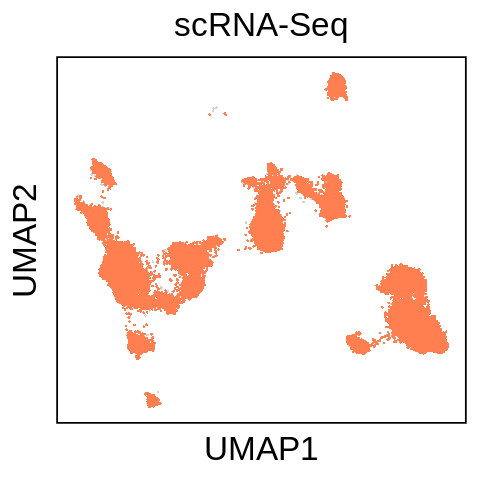

In [24]:
umap_plot = ggplot() +
  geom_point(
    data=select(qcd_meta, c(hUMAP1, hUMAP2, dataset)),
    aes(x = hUMAP1, y = hUMAP2),
    size = 0.75, stroke = 0.0001, color = "lightgrey"
  ) + 
  geom_point(
    data=qcd_meta %>% filter(dataset == "scRNAseq") %>% select(hUMAP1, hUMAP2),
    aes(x = hUMAP1, y = hUMAP2),
    size = 0.75, stroke = 0.0001, color = "coral"
  ) +
theme_classic(base_size = tickfontsize) +
  theme(
    legend.position = "none",
         plot.title = element_text(size = labelfontsize, hjust = 0.5),
          axis.title = element_text(size = labelfontsize), 
          axis.text = element_blank(),
          axis.line = element_blank(),
          axis.ticks = element_blank(),
          panel.border = element_rect(colour = "black", fill=NA, size=1),
          text=element_text(family="Arial")
  ) + labs(x = "UMAP1", y = "UMAP2", title = 'scRNA-Seq') 


outplot = umap_plot

height = 4
width = 4
fig.size(height, width)
outplot

ggsave(paste0(figdir, 'tnk_umap_sc.png'), plot = outplot,  
       height = height, width = width, dpi = 500)
ggsave(paste0(figdir, 'tnk_umap_sc.pdf'), plot = outplot,  
       height = height, width = width, dpi = 500, device = cairo_pdf)


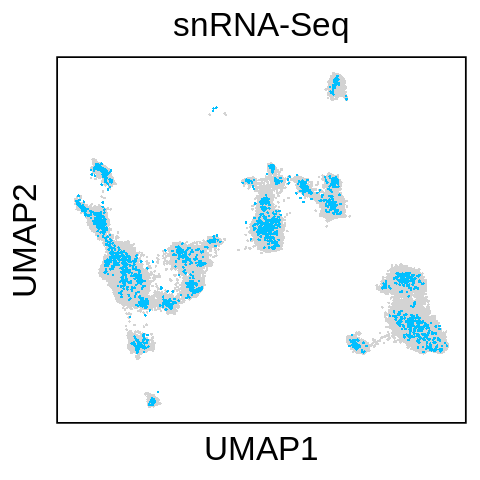

In [25]:
umap_plot = ggplot() +
  geom_point(
    data=select(qcd_meta, c(hUMAP1, hUMAP2, dataset)),
    aes(x = hUMAP1, y = hUMAP2),
    size = 0.75, stroke = 0.0001, color = "lightgrey"
  ) + 
  geom_point(
    data=qcd_meta %>% filter(dataset == "snRNAseq") %>% select(hUMAP1, hUMAP2),
    aes(x = hUMAP1, y = hUMAP2),
    size = 0.75, stroke = 0.0001, color = "deepskyblue"
  ) +
theme_classic(base_size = tickfontsize) +
  theme(
    legend.position = "none",
         plot.title = element_text(size = labelfontsize, hjust = 0.5),
          axis.title = element_text(size = labelfontsize), 
          axis.text = element_blank(),
          axis.line = element_blank(),
          axis.ticks = element_blank(),
          panel.border = element_rect(colour = "black", fill=NA, size=1),
          text=element_text(family="Arial")
  ) + labs(x = "UMAP1", y = "UMAP2", title = 'snRNA-Seq') 


outplot = umap_plot

height = 4
width = 4
fig.size(height, width)
outplot

ggsave(paste0(figdir, 'tnk_umap_sn.png'), plot = outplot,  
       height = height, width = width, dpi = 500)
ggsave(paste0(figdir, 'tnk_umap_sn.pdf'), plot = outplot,  
       height = height, width = width, dpi = 500, device = cairo_pdf)

### Cluster UMAPs

In [45]:
qcd_meta <- qcd_meta %>% filter(new_cluster_number != 12)

In [46]:
qcd_meta <- qcd_meta %>% mutate(new_cluster_number = ifelse(new_cluster_number > 12, new_cluster_number - 1, new_cluster_number))

In [47]:
final_annotation = data.frame(new_cluster_number = seq(0, 21), 
                               final_annotation = c("NK0. CD56dim NK",
                                             "T1. CD8+ GZMBhigh GZMHhigh CTL",
                                             "T2. CD8+ GZMBlow GZMHhigh CTL",
                                             "NK3. CD56bright NK",
                                             "T4. CENPF+ MKI67+ Proliferating",
                                             "T5. GZMK+ CD8+ CCL5high",
                                             "T6. GZMK+ CD8+ CCL5low",
                                             "T7. GZMK+ CD8+ Effector Memory",
                                             "T8. GZMK+ CD8+ NEAT1+",
                                             "T9. GZMK+ CD8+ Resident Memory",
                                             "T10. GZMK+ CD8+ ITGAE+ ITGA1+",
                                             "T11. CD4+ Effector Memory",
                                             "T12. CD8+ GMZK+ CD69+",
                                             "T13. CD4+ JUNlow Resident Memory",
                                             "T14. CD4+ JUNhigh Resident Memory",
                                             "T15. CD4+ S1PR1+ Central memory/Naive",
                                             "T16. KLRB1+ KIT+ ILC",
                                             "T17. CD4+ RORC+ CCR6+ Th17",
                                             "T18. CD4+ Central Memory/Naive",
                                             "T19. CD4+ IL2RA++ FOXP3++ Treg",
                                             "T20. CD4+ FOXP3+ CXCR5+ Central Memory/Naive",
                                             "T21. CD4+ PDCD1+ CXCR5+ TFH/TPH"))

qcd_meta <- qcd_meta %>% select(-final_annotation) %>% left_join(final_annotation)

Joining with `by = join_by(new_cluster_number)`


In [82]:
saveRDS(qcd_meta, '/data/srlab/ssg34/SLE_kidney_v2/data/qcd/T_NK_clusterQCd_meta_harmonizedPCUMAPclusters_annotations02062024.rds')

In [5]:
percent_mito <- readRDS('/data/srlab/ssg34/SLE_kidney_v2/data/tissue/percent_mito_from_rawcounts_12072023.rds')

In [8]:
qcd_meta <- readRDS('/data/srlab/ssg34/SLE_kidney_v2/data/qcd/T_NK_clusterQCd_meta_harmonizedPCUMAPclusters_annotations02062024.rds')

In [9]:
qcd_meta <- qcd_meta %>% 
                left_join(percent_mito) %>% 
                select(-arnon_cluster, arnon_annotations, annotation)
saveRDS(qcd_meta, '/data/srlab/ssg34/SLE_kidney_v2/data/qcd/T_NK_clusterQCd_meta_harmonizedPCUMAPclusters_annotations02062024.rds')

Joining, by = "cell"


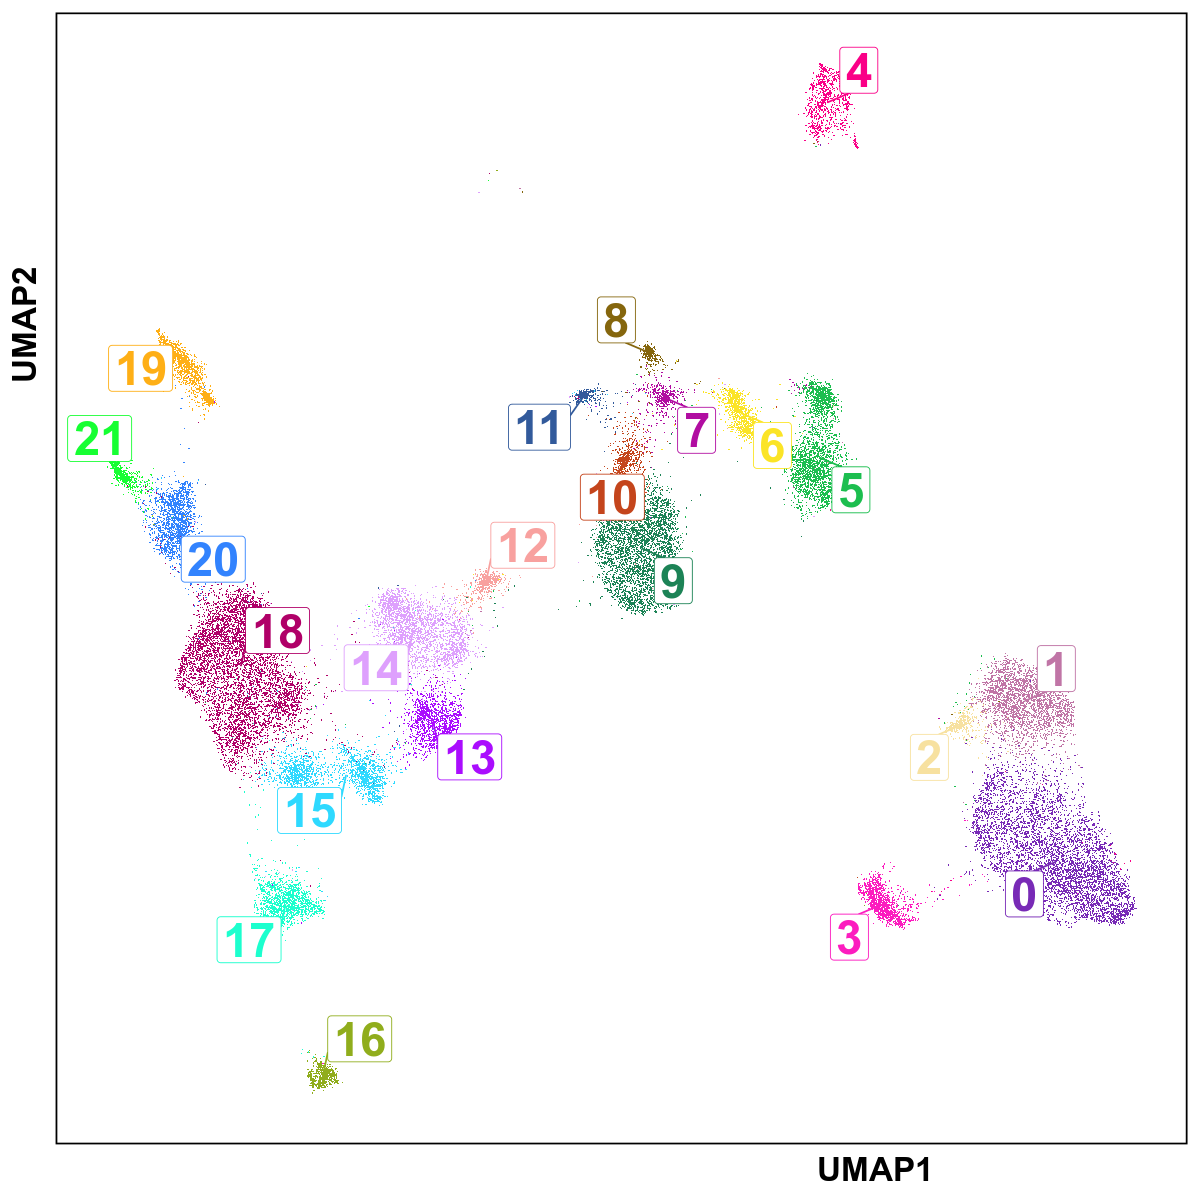

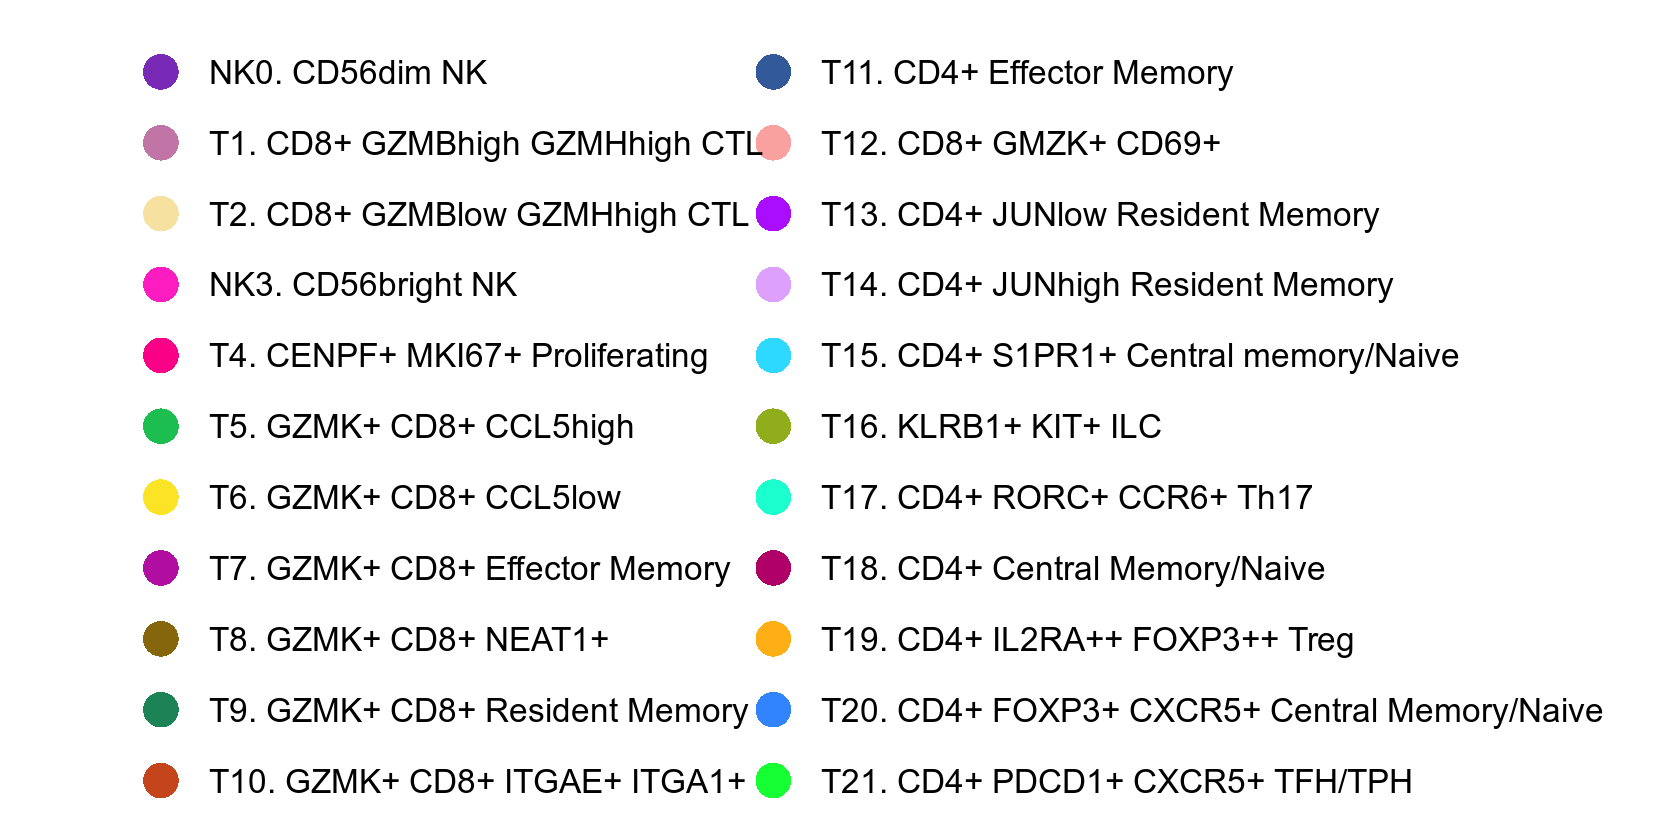

In [99]:
options(warn=-1)
cluster_center <- qcd_meta %>%
                  group_by(new_cluster_number, final_annotation) %>%
                  summarise_at(vars(hUMAP1, hUMAP2), funs(median(., na.rm=TRUE)))
cluster_center <- as.data.frame(cluster_center)

options(repr.plot.height = 9, repr.plot.width = 18)
p <- ggplot() +
      geom_point(
        data = qcd_meta[sample(nrow(qcd_meta)), ] %>% 
          select(hUMAP1, hUMAP2, new_cluster_number, final_annotation) %>% 
                  mutate(final_annotation = factor(final_annotation, 
                                                   levels = cluster_center$final_annotation)),
        aes(x = hUMAP1, y = hUMAP2, color = final_annotation),
          size = 0.6, shape = 20, stroke = 0.0001) +
      ggrepel::geom_label_repel(
        data = cluster_center,
        aes(x = hUMAP1, y = hUMAP2, 
            label = new_cluster_number, color = as.factor(final_annotation)),
        size = 10,  fontface = "bold",
        box.padding = unit(0.5, "lines"),
        point.padding = unit(0.01, "lines"),
        show.legend = FALSE
      ) +
        scale_color_manual(values =as.vector(rev(polychrome(26)))) +
    theme_classic(base_size = 15) +
      theme(
        legend.position = "right",
            #  plot.title = element_text(hjust = 0.5, 
            #                            size = 18, 
            #                            face = "bold"),
              axis.title = element_text(hjust = 0.75, 
                                        size = 20, 
                                        face = "bold"), 
              axis.text = element_blank(),
              axis.line = element_blank(),
              axis.ticks = element_blank(),
              panel.border = element_rect(colour = "black", fill=NA, size=1),
              legend.text = element_text(size = 20),
              legend.title = element_blank()
          
    ) +
    theme(text=element_text(family="Arial")) + 
        labs(x = "UMAP1", y = "UMAP2") +
        guides(color = guide_legend(ncol = 2, override.aes = list(size = 15)))
legend <- cowplot::get_legend(p)
p <- p + theme(legend.position = "none")
legend <- cowplot::plot_grid(legend)
cowplot::save_plot("/data/srlab/ssg34/SLE_kidney_v2/figures/main_figures/figure2/figure2a.png",
       p,
       base_height = 10,
       base_width = 10)
cowplot::save_plot("/data/srlab/ssg34/SLE_kidney_v2/figures/main_figures/figure2/figure2a-legend.png",
       legend,
       base_height = 7,
       base_width = 14)
fig.size(10, 10)
p
fig.size(7, 14)
legend
options(warn=0)

### Marker Gene UMAPs

In [8]:
markers = c('CD8A', 'CD4', 'TYROBP', 'SELL')

In [9]:
qcd_scaled = qcd_norm[markers, ] %>% scaleData
vmax = qcd_scaled %>% quantile(.95)
vmin = qcd_scaled %>% quantile(.05)

In [16]:
p = plot_shuffled_features(qcd_meta, qcd_scaled, markers[1], pt_size = 1, max.cutoff = vmax,
                          min.cutoff = vmin)
p1 = p + theme(legend.text = element_text(size = labelfontsize-2),
                legend.title = element_text(size = labelfontsize),
                plot.title = element_text(hjust = 0.5, size = labelfontsize),
               theme(text=element_text(family="Arial")),
              legend.position = "none") + labs(x = 'UMAP1', y = 'UMAP2')

p = plot_shuffled_features(qcd_meta, qcd_scaled, markers[2], pt_size = 1, max.cutoff = vmax,
                          min.cutoff = vmin)
p2 = p + theme(legend.text = element_text(size = labelfontsize-2),
                legend.title = element_text(size = labelfontsize),
                plot.title = element_text(hjust = 0.5, size = labelfontsize),
               theme(text=element_text(family="Arial")),
              legend.position = "none") + labs(x = 'UMAP1', y = 'UMAP2')

p = plot_shuffled_features(qcd_meta, qcd_scaled, markers[3], pt_size = 1, max.cutoff = vmax,
                          min.cutoff = vmin)
p3 = p + theme(legend.text = element_text(size = labelfontsize-2),
                legend.title = element_text(size = labelfontsize),
                plot.title = element_text(hjust = 0.5, size = labelfontsize),
               theme(text=element_text(family="Arial")),
              legend.position = "none") + labs(x = 'UMAP1', y = 'UMAP2')

p = plot_shuffled_features(qcd_meta, qcd_scaled, markers[4], pt_size = 1, max.cutoff = vmax,
                          min.cutoff = vmin)
p4 = p + theme(legend.text = element_text(size = labelfontsize-2),
                legend.title = element_text(size = labelfontsize),
                plot.title = element_text(hjust = 0.5, size = labelfontsize),
               theme(text=element_text(family="Arial")),
              legend.position = "none") + labs(x = 'UMAP1', y = 'UMAP2')

umap_legend = get_legend(p +theme(legend.text = element_text(size = labelfontsize-2),
                legend.title = element_text(size = labelfontsize),
                plot.title = element_text(hjust = 0.5, size = labelfontsize),
                theme(text=element_text(family="Arial"))))
umap_legend = cowplot::plot_grid(umap_legend) 

Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”


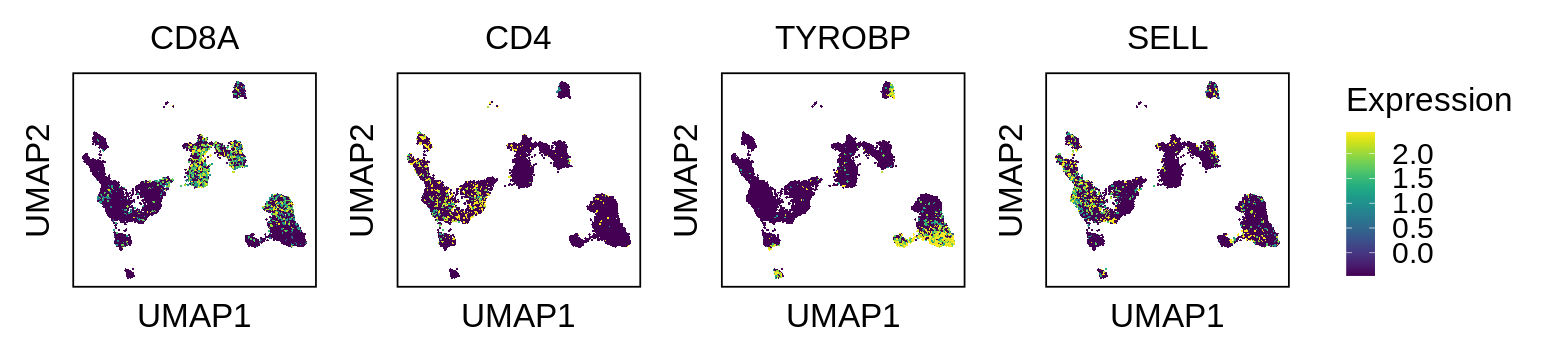

In [18]:
height = 3
width = 13
fig.size(height, width)

outplot = p1 + p2 + p3 + p4 + umap_legend + plot_layout(nrow = 1)
outplot

ggsave(paste0(figdir, 'tnk_umap_markers.png'), plot = outplot,  
       height = height, width = width, dpi = 500)
ggsave(paste0(figdir, 'tnk_umap_markers.pdf'), plot = outplot,  
       height = height, width = width, dpi = 500, device = cairo_pdf)

In [ ]:
 # G3 <- G1 + plot_spacer() + G2 + plot_layout(widths = c(4, -1.1 ,4.5),guides = "collect")& theme(legend.position = "top")


### Gene heatmaps

In [12]:
library(presto)

In [13]:
marker_genes = c("CD3D", "CD4", "CD8A", "CD28", "CCR7", "SELL", "S1PR1", "NCAM1", "GNLY", "FCGR3A",
                  "PRF1", "GZMH", "GZMB", "CENPF", "MKI67", "CCL5", "GZMK", 
                  "NEAT1", "ITGAE", "ITGA1", "CD69", "JUN", "KLRB1", "KIT", "IL1R1", "IL7R",
                  "RORC", "CCR6", "IL2RA", "FOXP3", "CXCR5", "PDCD1")
# <- c("NCAM1", "TYROBP", "PRF1", "GZMK", "GZMB", "SYNE2", "CD3D", "CD4", "CD8A", "CENPF", "MKI67", "NKG7", 
#                  "CD28", "CCR7", "SELL", "ITGAE", "NEAT1", "S1PR1", "CD69", "JUN", "KLRB1", "KIT", "IL1R1", "IL7R",
#                   "RORC", "CCR6", "IL2RA", "FOXP3", "PDCD1", "CXCR5")

In [14]:
annotation.order = c("NK0. CD56dim NK",
                     "NK3. CD56bright NK",
                     "T1. CD8+ GZMBhigh GZMHhigh CTL",
                     "T2. CD8+ GZMBlow GZMHhigh CTL",
                     "T4. CENPF+ MKI67+ Proliferating",
                     "T5. GZMK+ CD8+ CCL5high",
                     "T6. GZMK+ CD8+ CCL5low",
                     "T7. GZMK+ CD8+ Effector Memory",
                     "T8. GZMK+ CD8+ NEAT1+",
                     "T9. GZMK+ CD8+ Resident Memory",
                     "T10. GZMK+ CD8+ ITGAE+ ITGA1+",
                     "T11. CD4+ Effector Memory",
                     "T12. CD8+ GMZK+ CD69+",
                     "T13. CD4+ JUNlow Resident Memory",
                     "T14. CD4+ JUNhigh Resident Memory",
                     "T15. CD4+ S1PR1+ Central memory/Naive",
                     "T16. KLRB1+ KIT+ ILC",
                     "T17. CD4+ RORC+ CCR6+ Th17",
                     "T18. CD4+ Central Memory/Naive",
                     "T19. CD4+ IL2RA++ FOXP3++ Treg",
                     "T20. CD4+ FOXP3+ CXCR5+ Central Memory/Naive",
                     "T21. CD4+ PDCD1+ CXCR5+ TFH/TPH")

In [15]:
library(googlesheets4)
gs4_deauth()

tissue_names = read_sheet("https://docs.google.com/spreadsheets/d/1f94hwyuDMvSUQyelWM89xfhDos7izNQw9bQ4amml2OQ/edit?usp=sharing", 
                 sheet = "Tissue")
tissue_names = setNames(tissue_names$Annotation_latest, tissue_names$Annotation_v1)
qcd_meta = qcd_meta %>% mutate(final_annotation = recode(final_annotation, !!!tissue_names))

annotation.order = recode(annotation.order, !!!tissue_names)

✔ Reading from UpdatedClusterNames.

✔ Range ''Tissue''.



In [16]:
annotation.order

[1] "NK0. CD56dim NK"                      
 [2] "NK1. CD56bright NK"                   
 [3] "T2. CD8+ GZMB+ CTL"                   
 [4] "T3. CD8+ GZMB+ SYNE2bright CTL"       
 [5] "T4. CENPF+ MKI67+ Proliferating"      
 [6] "T5. GZMK+ CD8+ NKG7high"              
 [7] "T6. GZMK+ CD8+ NKG7low"               
 [8] "T7. GZMK+ CD8+ Effector Memory"       
 [9] "T8. GZMK+ CD8+ NEAT1+"                
[10] "T9. GZMK+ CD8+ Resident Memory"       
[11] "T10. GZMK+ CD8+ ITGAE"                
[12] "T11. CD4+ Effector Memory"            
[13] "T12. CD8+ GMZK+ CD69+"                
[14] "T13. CD4+ JUNlow Resident Memory"     
[15] "T14. CD4+ JUNhigh Resident Memory"    
[16] "T15. CD4+ S1PR1+ Central memory/Naive"
[17] "T16. KLRB1+ KIT+ ILC"                 
[18] "T17. CD4+ RORC+ CCR6+ Th17"           
[19] "T18. CD4+ Central Memory/Naive"       
[20] "T19. CD4+ IL2RA++ FOXP3++ Treg"       
[21] "T20. CD4+ FOXP3+ Central Memory/Naive"
[22] "T21. CD4+ PDCD1+ CXCR5+ TFH/TPH"

In [17]:
wilcox_sn <- wilcoxauc(qcd_norm[, qcd_meta %>% filter(dataset == 'snRNAseq') %>% pull(cell)], 
                       qcd_meta %>% filter(dataset == 'snRNAseq') %>% pull(final_annotation))
wilcox_sc <- wilcoxauc(qcd_norm[, qcd_meta %>% filter(dataset == 'scRNAseq') %>% pull(cell)], 
                       qcd_meta %>% filter(dataset == 'scRNAseq') %>% pull(final_annotation))

In [18]:
sc_plot_df <- wilcox_sc %>%  filter(feature %in% marker_genes) %>% 
                    select(group, feature, 
                           logFC, avgExpr, pct_in) %>% ungroup() %>% group_by(feature) %>% 
                    mutate(avgExpr_scaled = scale(avgExpr)) 
sn_plot_df <- wilcox_sn %>%  filter(feature %in% marker_genes) %>% 
                    select(group, feature, 
                           logFC, avgExpr, pct_in) %>% ungroup() %>% group_by(feature) %>% 
                    mutate(avgExpr_scaled = scale(avgExpr)) 

In [19]:
setdiff(sc_plot_df$group, annotation.order)

character(0)

In [20]:
title = 'scRNA-seq'
dat_all = sc_plot_df %>% rename(percent = pct_in, zscore = avgExpr_scaled) 

dat = dat_all %>% pivot_wider(id_cols = 'feature', names_from = 'group', 
                    values_from = 'zscore') %>% as.data.frame
rownames(dat) = dat$feature
dat = dat %>% select(-feature)
row.order = marker_genes
col.order = annotation.order
# row.order = rownames(dat)[hclust(dist(dat))$order]
# col.order = colnames(dat)[hclust(dist(t(dat)))$order]
dat = dat_all
dat$group = factor(dat$group, levels = col.order)
dat$feature = factor(dat$feature, levels = row.order)

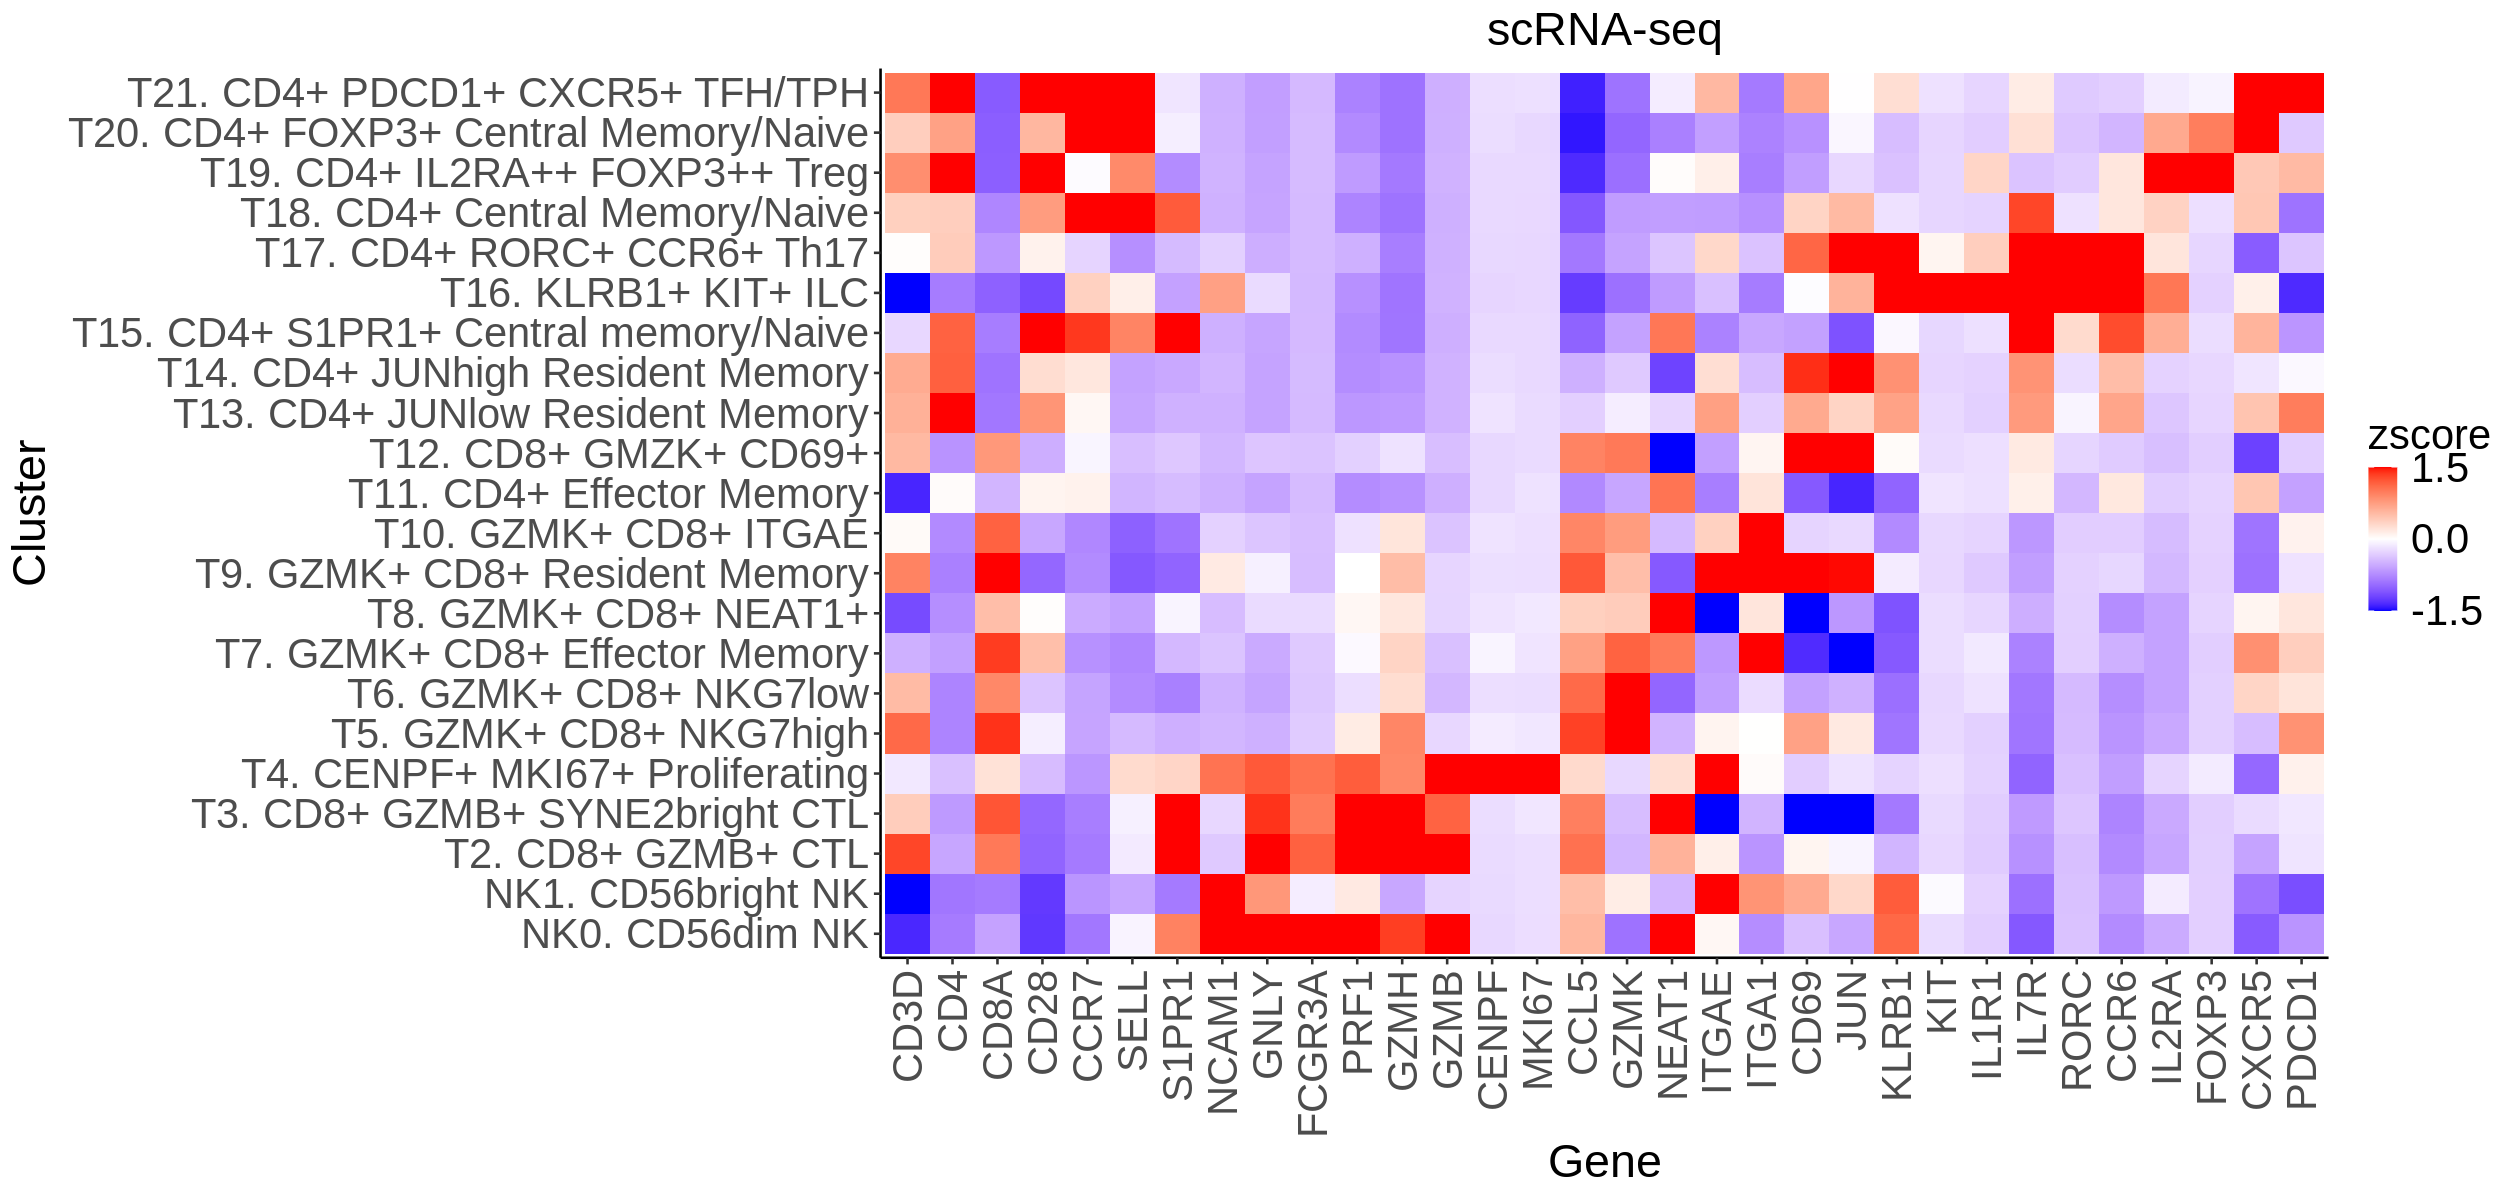

In [22]:
height = 10
width = 21
fig.size(height, width)


marker_heatmap = ggplot(dat, 
               aes(x = feature, y = group, 
                   fill = zscore)) + 
    geom_tile() + 
    theme_classic(base_size = tickfontsize) + 
    scale_fill_gradient2(low = "blue",
                         mid = "white",
                         high= "red", 
                         limits=c(-1.5, 1.5), 
                         oob = scales::squish, breaks = c(-1.5, 0, 1.5)) + 
    # scale_x_discrete(limits = marker_genes) + 
    # scale_y_discrete(limits = final_annotation$final_annotation) + 
    theme(axis.text.x = element_text(angle = 90, hjust = 1, vjust = .5),
          axis.text = element_text( size = labelfontsize+5),
          axis.title = element_text(size = labelfontsize+8), 
          plot.title = element_text(size = labelfontsize+8, hjust = 0.5), 
          legend.text = element_text(size = labelfontsize+5),
          legend.title = element_text(size = labelfontsize+5)

         ) + 
    labs(x = "Gene", y = "Cluster", title = title)

outplot = marker_heatmap
outplot

ggsave(paste0(figdir, 'tnk_sc_heatmap_markers.png'), plot = outplot,  
       height = height, width = width, dpi = 500)
ggsave(paste0(figdir, 'tnk_sc_heatmap_markers.pdf'), plot = outplot,  
       height = height, width = width, dpi = 500, device = cairo_pdf)

In [23]:
title = 'snRNA-seq'
dat_all = sn_plot_df %>% rename(percent = pct_in, zscore = avgExpr_scaled) 

# dat = dat_all %>% pivot_wider(id_cols = 'feature', names_from = 'group', 
#                     values_from = 'zscore') %>% as.data.frame
# rownames(dat) = dat$feature
# dat = dat %>% select(-feature)
# row.order = rownames(dat)[hclust(dist(dat))$order]
# col.order = colnames(dat)[hclust(dist(t(dat)))$order]
dat = dat_all
dat$group = factor(dat$group, levels = col.order)
dat$feature = factor(dat$feature, levels = row.order)

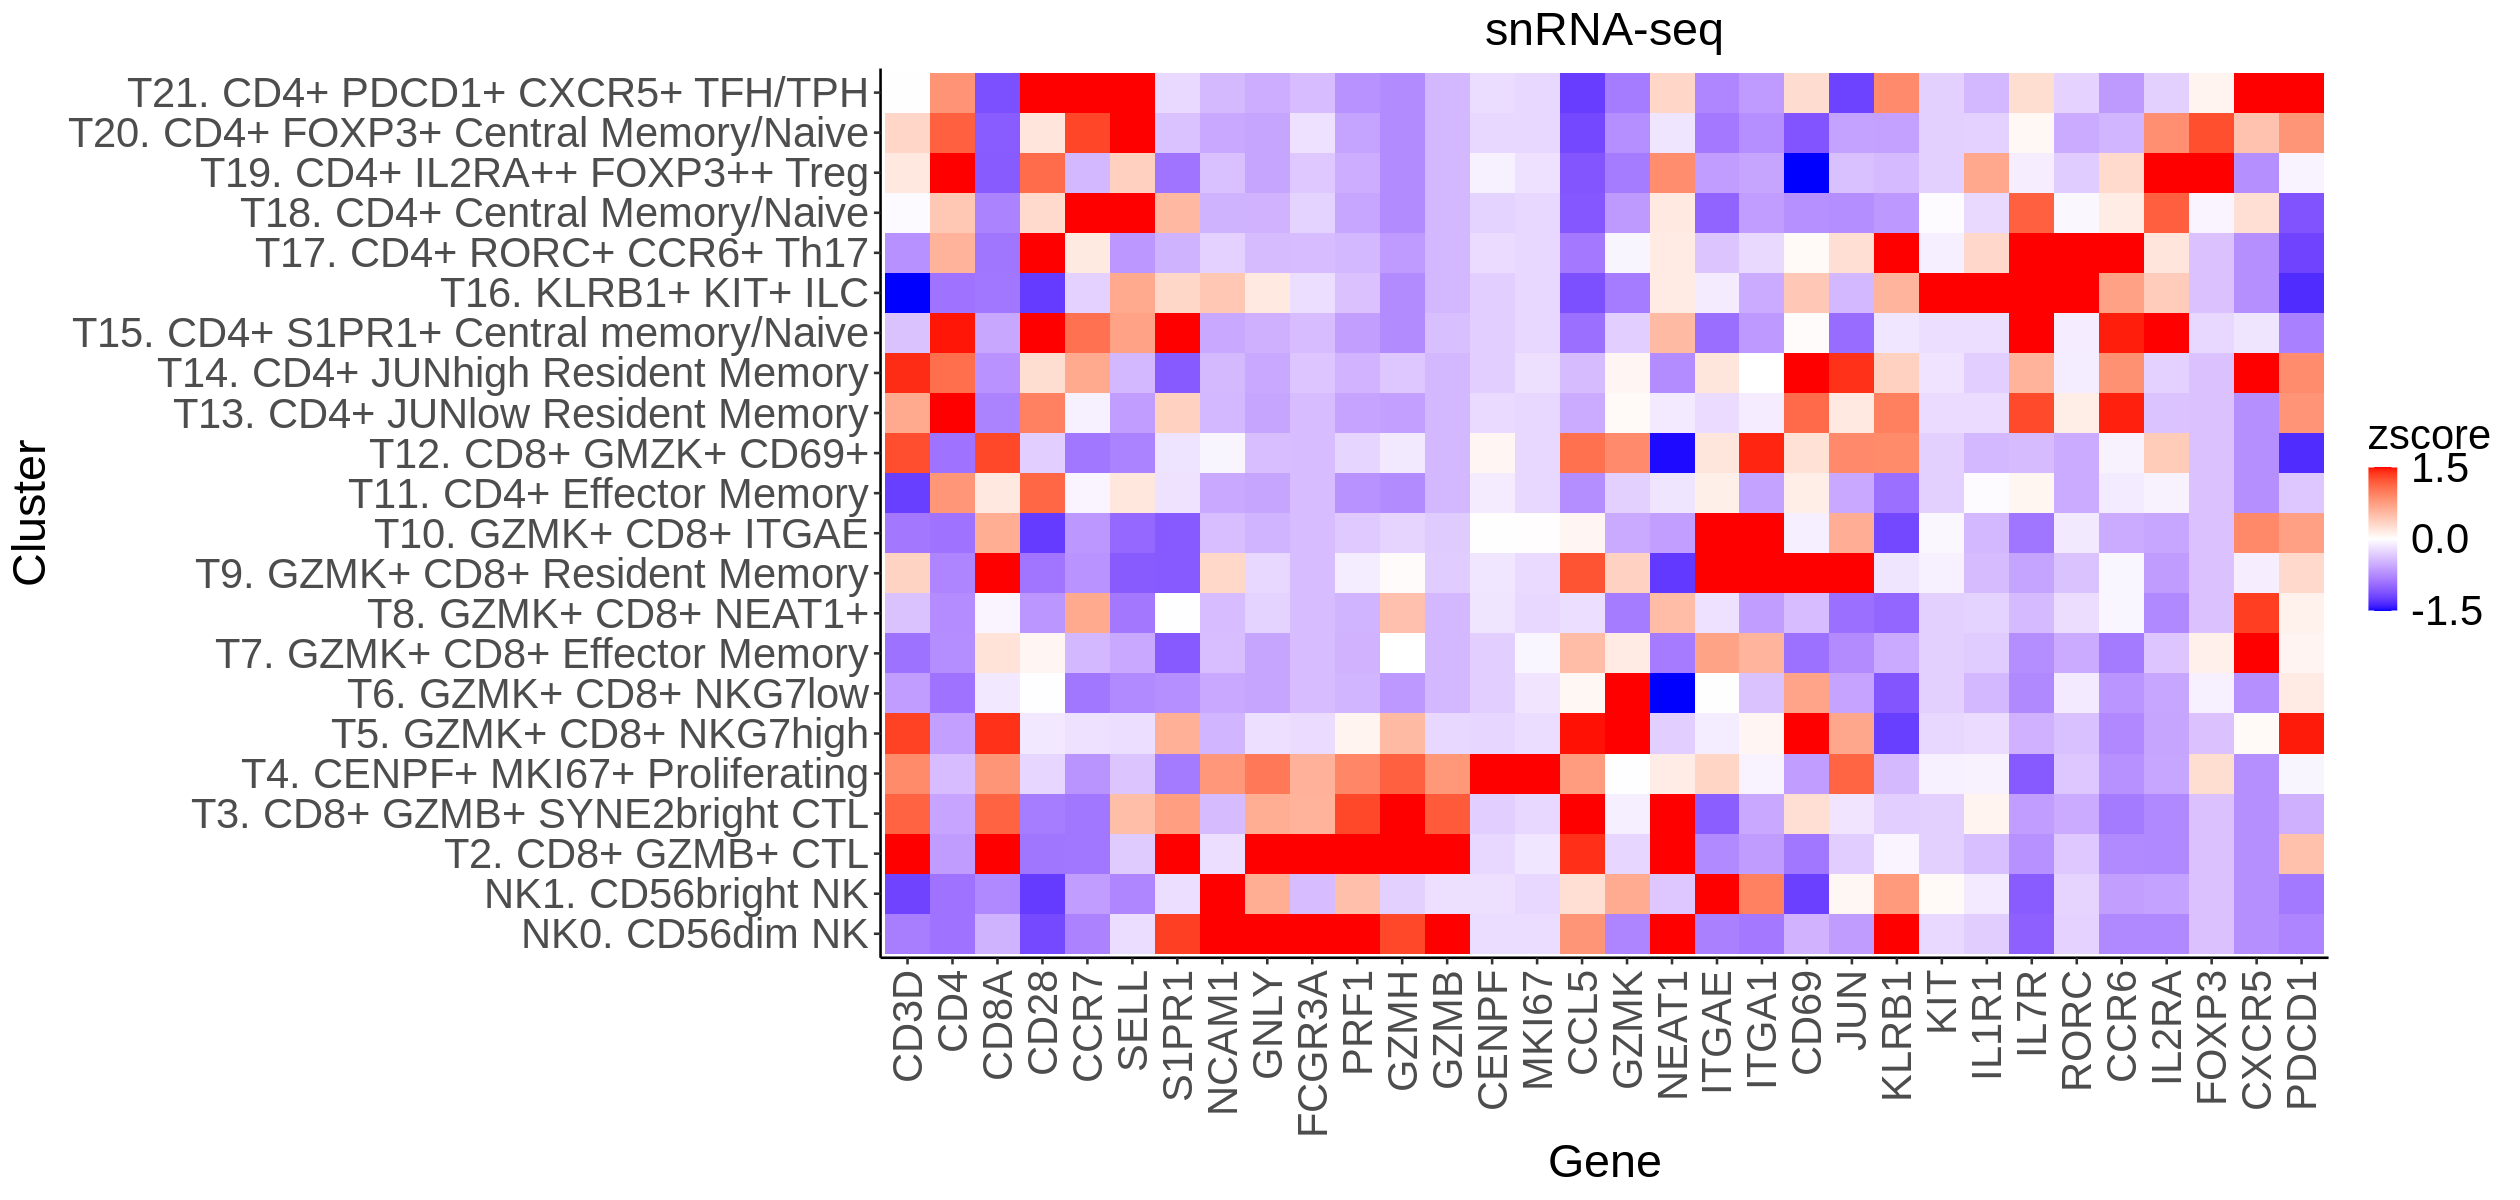

In [24]:
height = 10
width = 21
fig.size(height, width)


marker_heatmap = ggplot(dat, 
               aes(x = feature, y = group, 
                   fill = zscore)) + 
    geom_tile() + 
    theme_classic(base_size = tickfontsize) + 
    scale_fill_gradient2(low = "blue",
                         mid = "white",
                         high= "red", 
                         limits=c(-1.5, 1.5), 
                         oob = scales::squish, breaks = c(-1.5, 0, 1.5)) + 
    # scale_x_discrete(limits = marker_genes) + 
    # scale_y_discrete(limits = final_annotation$final_annotation) + 
    theme(axis.text.x = element_text(angle = 90, hjust = 1, vjust = .5),
          axis.text = element_text( size = labelfontsize+5),
          axis.title = element_text(size = labelfontsize+8), 
          plot.title = element_text(size = labelfontsize+8, hjust = 0.5), 
          legend.text = element_text(size = labelfontsize+5),
          legend.title = element_text(size = labelfontsize+5)

         ) + 
    labs(x = "Gene", y = "Cluster", title = title)

outplot = marker_heatmap
outplot

ggsave(paste0(figdir, 'tnk_sn_heatmap_markers.png'), plot = outplot,  
       height = height, width = width, dpi = 500)
ggsave(paste0(figdir, 'tnk_sn_heatmap_markers.pdf'), plot = outplot,  
       height = height, width = width, dpi = 500, device = cairo_pdf)

### Cluster Proportions in Matched Patients

In [25]:
qcd_meta <- qcd_meta  %>% 
                mutate(individual = str_split(sample, '_')) %>% 
                rowwise() %>% 
                mutate(individual = unlist(individual)[3]) 

In [26]:
sample_freq <- qcd_meta %>% select(dataset, individual, new_cluster_number) %>% 
                    table() %>% data.frame() %>% 
                    pivot_wider(names_from = "new_cluster_number", values_from = Freq) 

In [27]:
ind_list <- qcd_meta %>% select(dataset, individual) %>% 
                table() %>% data.frame() %>% 
                pivot_wider(names_from = 'dataset', values_from = "Freq") %>% filter(scRNAseq > 40 & snRNAseq > 40) %>% 
                pull(individual)

In [28]:
sample_freq_sc <- sample_freq %>% 
                    filter(individual %in% ind_list) %>% 
                    select(- individual) %>% 
                    filter(dataset == "scRNAseq") %>% 
                    select(-dataset) %>% colSums()

sample_freq_sn <- sample_freq %>% 
                    filter(individual %in% ind_list) %>% 
                    select(- individual) %>% 
                    filter(dataset == "snRNAseq") %>% 
                    select(-dataset) %>% colSums()

In [51]:
sample_freq_sc           

0    1    2    3    4    5    6    7    8    9   10   11   12   13   14   15 
 766  430   62  283  129  520  209  104   53  673  130   58  107  256  497  371 
  16   17   18   19   20   21 
 128  280 1273  272  316  101

In [29]:
sample_freq <- data.frame(rep("a", 22))
sample_freq$sc_freq <- sample_freq_sc / sum(sample_freq_sc)
sample_freq$sc_se <- sqrt((sample_freq$sc_freq * (1 - sample_freq$sc_freq)) / sample_freq_sc)
sample_freq$sn_freq <- sample_freq_sn / sum(sample_freq_sn)
sample_freq$sn_se <- sqrt((sample_freq$sn_freq * (1 - sample_freq$sn_freq)) / sample_freq_sn)
sample_freq <- sample_freq[,- 1]
sample_freq$new_cluster_number <- as.character(seq(0, 21))

In [30]:
r = cor(sample_freq$sc_freq, sample_freq$sn_freq)
pval = cor.test(sample_freq$sc_freq, sample_freq$sn_freq)$p.value

In [31]:
format(pval, format = 'e', digits = 3)

[1] "6.43e-11"

In [33]:
title = 'T/NK'

In [50]:
sample_freq

sc_freq,sc_se,sn_freq,sn_se,new_cluster_number
<dbl>,<dbl>,<dbl>,<dbl>,<chr>
0.109147905,0.01126668,0.08421053,0.02195437,0
0.061271017,0.01156547,0.04263158,0.02244723,1
0.008834426,0.01188410,0.01105263,0.02281444,2
0.040324879,0.01169379,0.02947368,0.02260096,3
0.018381305,0.01182673,0.02421053,0.02266216,4
0.074095184,0.01148620,0.06789474,0.02214908,5
0.029780564,0.01175786,0.04052632,0.02247190,6
0.014819037,0.01184817,0.01526316,0.02276582,7
0.007552009,0.01189179,0.01842105,0.02272929,8


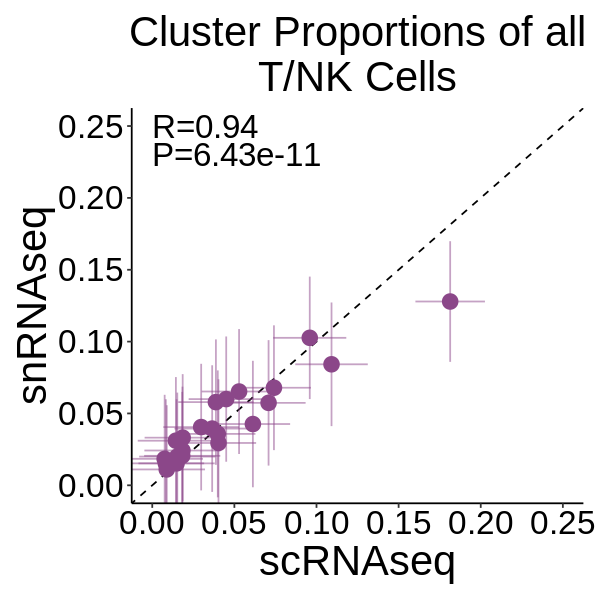

In [49]:
max_val <- max(sample_freq[, c("sc_freq", "sn_freq")])

p = ggplot(sample_freq, aes(x = sc_freq, y = sn_freq)) + 
    geom_abline(linetype = "dashed") +
    # scale_color_manual(values =as.vector(rev(palette36.colors(26)))) +
    theme_classic() + 
    geom_linerange(aes(ymax = sn_freq+1.96*sn_se, 
                        ymin = sn_freq-1.96*sn_se), alpha = 0.5, color = 'orchid4') +
    geom_linerange(aes(xmax = sc_freq+1.96*sc_se, 
                        xmin = sc_freq-1.96*sc_se), alpha = 0.5, color = 'orchid4') +
    geom_point(size = 4, color = 'orchid4') + 
    theme(legend.position = "none",
          axis.text = element_text(size = 15),
          axis.title = element_text(size = 18)) +
    coord_cartesian(xlim = c(0, 0.25), ylim = c(0, 0.25)) + 
    labs(x = "scRNAseq",
         y = "snRNAseq", title = paste0('Cluster Proportions of all\n', title, ' Cells'))+
    annotate("text", x = 0, y = 0.25, label = paste0('R=', round(r, 2)), hjust =0, 
         size =7)+
    annotate("text", x = 0, y = 0.23, label = paste0('P=', 
             format(pval, format = 'e', digits = 3)), hjust =0, 
         size =7)

p = p +theme(axis.text = element_text(color = "black", size = labelfontsize, vjust = 0.5),
           axis.title = element_text(size=labelfontsize+5, hjust = 0.5),
            legend.text = element_text(size = labelfontsize),
            legend.title = element_text(size = labelfontsize),
                plot.title = element_text(hjust = 0.5, size = labelfontsize+5),
                theme(text=element_text(family="Arial")),
                                    plot.margin = margin(10, 10, 10, 10))
height = 5
width = 5
fig.size(height, width)

outplot = p
outplot

ggsave(paste0(figdir, 'tnk_scsn_cellfreqcorr.png'), plot = outplot,  
       height = height, width = width, dpi = 500)
ggsave(paste0(figdir, 'tnk_scsn_cellfreqcorr.pdf'), plot = outplot,  
       height = height, width = width, dpi = 500, device = cairo_pdf)

In [46]:
labelfontsize

[1] 20

In [129]:
cor.test(sample_freq$sc_freq, sample_freq$sn_freq)


	Pearson's product-moment correlation

data:  sample_freq$sc_freq and sample_freq$sn_freq
t = 12.517, df = 20, p-value = 6.428e-11
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 0.8625489 0.9758631
sample estimates:
      cor 
0.9417005 
